<a href="https://colab.research.google.com/github/Zahraghasemzadeh/rPPG/blob/main/filter_rPPG_aug_cPPg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import resample
from scipy.signal import butter, filtfilt, savgol_filter, detrend
import pywt
import matplotlib.pyplot as plt
import os
from google.colab import drive
import gdown
import zipfile
import shutil

In [5]:
FILE_ID = "16jlBsawf1rOefEaxpSbd_dPspnrZS2nB"
ZIP_PATH = "/content/ppg_arrhythmia.zip"
DATA_PATH = "/content/data"
# ---------------------

# 1. Clean up (from previous runs)
if os.path.exists(DATA_PATH):
    print(f"🧹 Removing existing '{DATA_PATH}' folder...")
    shutil.rmtree(DATA_PATH)

# 2. Download
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

# 3. Extract
print(f"\n📂 Extracting dataset...")
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/") # Extract to the parent directory
except zipfile.BadZipFile:
    print(f"❌ Error: Failed to open zip file. Download may have been corrupted.")
    # Stop execution if zip is bad
    raise

# 4. Clean up Zip
print("\n🧹 Deleting zip file...")
os.remove(ZIP_PATH)

# 5. Verify
if os.path.exists(DATA_PATH):
    print(f"\n✅ Success! Dataset is ready in the '{DATA_PATH}' folder.")

    print(f"\n📁 Contents of '{DATA_PATH}' :")
    try:
        # List only the first 5 items
        contents = os.listdir(DATA_PATH)
        print(f"  {contents[:5]} {'...' if len(contents) > 5 else ''}")
    except Exception as e:
        print(f"  Could not list contents: {e}")
else:
    print(f"❌ Error: Final directory '{DATA_PATH}' not found after extraction.")
    print("   Please check the zip file's internal structure.")

Downloading...
From (original): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB
From (redirected): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB&confirm=t&uuid=471af06b-1a66-43e4-ae2b-f022eaa71234
To: /content/ppg_arrhythmia.zip
100%|██████████| 353M/353M [00:15<00:00, 22.4MB/s]



📂 Extracting dataset...

🧹 Deleting zip file...

✅ Success! Dataset is ready in the '/content/data' folder.

📁 Contents of '/content/data' :
  ['train', 'test', 'README.md'] 


In [6]:
# ==================== LOAD DATASET ====================
train_segments = np.load(os.path.join(DATA_PATH, 'train', 'train_segments.npy'))
train_labels   = np.load(os.path.join(DATA_PATH, 'train', 'train_labels.npy'))
test_segments  = np.load(os.path.join(DATA_PATH, 'test', 'test_segments.npy'))
test_labels    = np.load(os.path.join(DATA_PATH, 'test', 'test_labels.npy'))

# ==================== BASIC STATISTICS ====================
n_train, n_samples = train_segments.shape
n_test = test_segments.shape[0]

print("=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)
print(f"✅ Training samples    : {n_train:,}")
print(f"🧪 Test samples        : {n_test:,}")
print(f"📏 Samples per segment : {n_samples:,}")
print(f"💾 Data type           : {train_segments.dtype}")
print()

# ==================== CLASS DISTRIBUTION ====================
train_class_counts = np.bincount(train_labels)
test_class_counts = np.bincount(test_labels)

print("-" * 60)
print("🏷️  LABEL DISTRIBUTION")
print("-" * 60)
print("TRAINING SET:")
print(f"   Class 0 (Healthy)    : {train_class_counts[0]:,} samples ({train_class_counts[0]/n_train*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {train_class_counts[1]:,} samples ({train_class_counts[1]/n_train*100:.1f}%)")
print()
print("TEST SET:")
print(f"   Class 0 (Healthy)    : {test_class_counts[0]:,} samples ({test_class_counts[0]/n_test*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {test_class_counts[1]:,} samples ({test_class_counts[1]/n_test*100:.1f}%)")
print()


# ==================== TEMPORAL CHARACTERISTICS ====================
segment_duration_sec = 10.0
sampling_rate = n_samples / segment_duration_sec

train_hours = (n_train * segment_duration_sec) / 3600
test_hours = (n_test * segment_duration_sec) / 3600
total_hours = train_hours + test_hours

print("-" * 60)
print("⏱️  TEMPORAL PROPERTIES")
print("-" * 60)
print(f"   Sampling rate        : {sampling_rate:.1f} Hz")
print(f"   Segment duration     : {segment_duration_sec:.1f} seconds")
print(f"   Training data        : {train_hours:.2f} hours")
print(f"   Test data            : {test_hours:.2f} hours")
print(f"   Total recording time : {total_hours:.2f} hours")
print("=" * 60)

📊 DATASET SUMMARY
✅ Training samples    : 35,120
🧪 Test samples        : 11,707
📏 Samples per segment : 1,000
💾 Data type           : float64

------------------------------------------------------------
🏷️  LABEL DISTRIBUTION
------------------------------------------------------------
TRAINING SET:
   Class 0 (Healthy)    : 10,953 samples (31.2%)
   Class 1 (Arrhythmic) : 24,167 samples (68.8%)

TEST SET:
   Class 0 (Healthy)    : 3,651 samples (31.2%)
   Class 1 (Arrhythmic) : 8,056 samples (68.8%)

------------------------------------------------------------
⏱️  TEMPORAL PROPERTIES
------------------------------------------------------------
   Sampling rate        : 100.0 Hz
   Segment duration     : 10.0 seconds
   Training data        : 97.56 hours
   Test data            : 32.52 hours
   Total recording time : 130.07 hours


## 2️⃣ Dataset Overview & Exploration

### 📋 What You're Working With

You've been provided with **photoplethysmography (PPG) signals** — these are physiological time-series recordings that capture blood volume changes. Your mission: build a model that can distinguish between healthy and arrhythmic heart rhythms!

---

### 📊 DATASET SPECIFICATIONS

|                    | Training | Test   | Total  |
|--------------------|----------|--------|--------|
| **Samples**        | 35,120   | 11,707 | 46,827 |
| **Duration**       | 97.6 hrs | 32.5 hrs | 130.1 hrs |
| **Segment Length** | 10 seconds @ 100 Hz (1,000 samples) |
| **Class Distribution** | Healthy: 31.2% / Arrhythmic: 68.8% |

---

### 🗂️ Dataset Structure
```
data/
├── train/
│   ├── train_segments.npy    # Training PPG signals
│   └── train_labels.npy       # Ground truth labels
└── test/
    ├── test_segments.npy      # Test PPG signals
    └── test_labels.npy        # Test labels
```

### 🏷️ Labels
- **0** = Healthy rhythm (normal cardiac activity)
- **1** = Arrhythmic rhythm (irregular cardiac activity)

---

### Signal Characteristics
- **Sampling rate**: 100 Hz
- **Segment duration**: 10 seconds per sample
- **Data format**: NumPy arrays (.npy)
- **Samples per segment**: 1,000 values

Each sample is a **~10-second PPG segment** stored as a 1-D array. This is a **binary classification** problem — predict the label for each test segment!


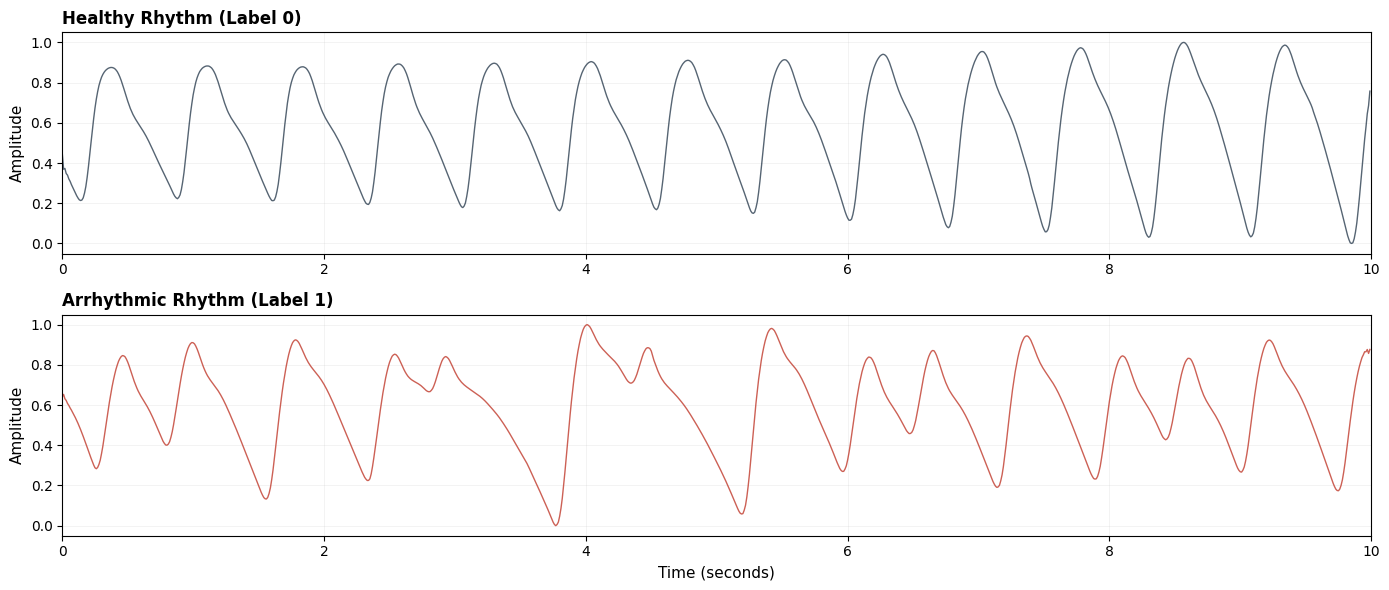

In [7]:
# ==================== SELECT SAMPLE SIGNALS ====================
idx_healthy = np.where(train_labels == 0)[0][1]  # First healthy sample
idx_arr = np.random.choice(np.where(train_labels == 1)[0])  # Random arrhythmic sample

# Calculate time axis in seconds
sampling_rate = 100  # Hz
time_axis = np.arange(n_samples) / sampling_rate

# ==================== PLOT COMPARISON ====================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='white')

# Healthy rhythm
axes[0].plot(time_axis, train_segments[idx_healthy], linewidth=1, color='#2c3e50', alpha=0.8)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Healthy Rhythm (Label 0)', fontsize=12, loc='left', fontweight='600')
axes[0].grid(True, alpha=0.2, linewidth=0.5)
axes[0].set_xlim(0, 10)

# Arrhythmic rhythm
axes[1].plot(time_axis, train_segments[idx_arr], linewidth=1, color='#c0392b', alpha=0.8)
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Arrhythmic Rhythm (Label 1)', fontsize=12, loc='left', fontweight='600')
axes[1].grid(True, alpha=0.2, linewidth=0.5)
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

In [125]:
rppg_signal = np.load("rppg_20251108-114228.npy" )
print("rppg_signal_shape:",rppg_signal.shape)
# extracted signal is 30 sec with 30 samples per sec

rppg_signal_shape: (768,)


In [126]:
# --- Resample to cPPG length for comparison ---
fs_rppg = 30  # original rPPG recording fps
total_sec = len(rppg_signal)/fs_rppg  #  sec
print('sig dur:',total_sec)
seg_len_sec = 10

num_segments = int(total_sec // seg_len_sec)  # 2
print(num_segments)

sig dur: 25.6
2


In [128]:
segments_resampled = []

for i in range(num_segments):
    seg = rppg_signal[i*seg_len_sec*fs_rppg:(i+1)*seg_len_sec*fs_rppg]
    seg_res = resample(seg, 1000)  # resample to match cPPG
    segments_resampled.append(seg_res)

In [129]:
signal_raw = np.concatenate(segments_resampled, axis=0)
print(signal_raw.shape)   # (2000,)

(2000,)


## **Denoising**

In [41]:
def bandpass(sig, low, high, fs, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, sig)

In [42]:
def smooth_signal(signal, window_length=11, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

In [43]:
def znorm(x):
    x = x - x.mean()
    s = x.std() if x.std() != 0 else 1.0
    return x / s

In [91]:
def preprocess_rppg_segment(seg ):
    seg_bp = bandpass(seg,low = 0.7,high = 3.0 , fs =100)
    seg_sg = smooth_signal(seg_bp, window_length=11, polyorder=3)
    seg_dt = detrend(seg_sg)
    seg_norm = znorm(seg_dt)
    return seg_norm

In [130]:
signal = signal_raw          # 1D array, e.g. length 2000
window_size = 1000                   # must match train_segments.shape[1]
step = 1                             # 1 → fully overlapping windows

N = len(signal)
num_windows = N - window_size + 1    # for step = 1

segments_filtered = np.zeros((num_windows, window_size), dtype=np.float32)

for i in range(num_windows):
    window = signal[i : i + window_size]            # shape (1000,)
    window_proc = preprocess_rppg_segment(window)   # expect shape (1000,)
    segments_filtered[i] = window_proc              # put in row i

print(segments_filtered.shape)
# → (num_windows, 1000)  = (1001, 1000)

(1001, 1000)


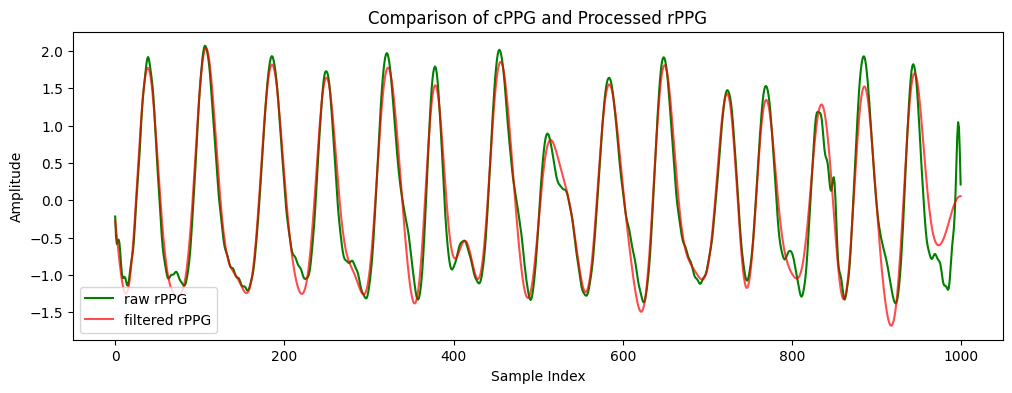

In [131]:
# --- Plot comparison ---
plt.figure(figsize=(12,4))
plt.plot(signal_raw[:1000], label="raw rPPG", color='green')
plt.plot(segments_filtered[0], label="filtered rPPG", color='red', alpha=0.7)
plt.title("Comparison of cPPG and Processed rPPG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


In [132]:
cppg_norm = znorm(train_segments)

In [133]:
print(cppg_norm.shape)
print(segments_filtered.shape)

(35120, 1000)
(1001, 1000)


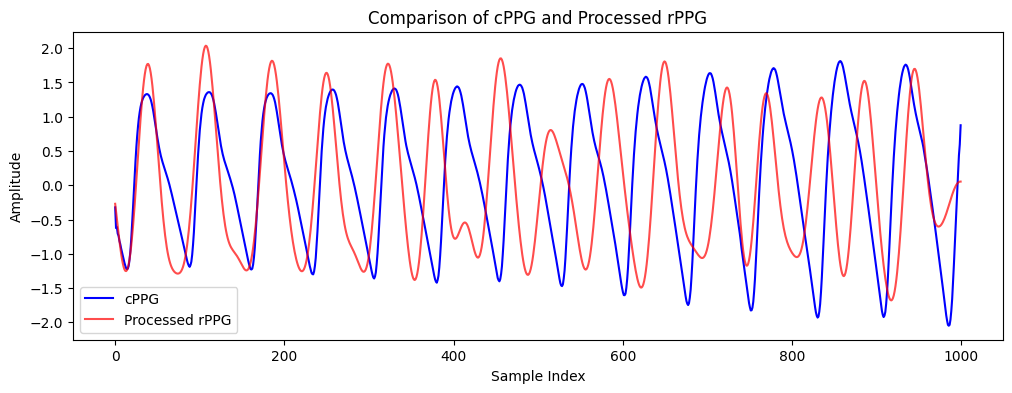

In [134]:
# --- Plot comparison ---
plt.figure(figsize=(12,4))
plt.plot(cppg_norm[idx_healthy], label="cPPG", color='blue')
plt.plot(segments_filtered[0], label="Processed rPPG", color='red', alpha=0.7)
plt.title("Comparison of cPPG and Processed rPPG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


From the figure, your cPPG and processed rPPG are already very similar:

same general frequency / heart rate

rPPG is a bit smoother,

a bit phase-shifted,

slightly different amplitude / offset

## Data Augmentation
### add gaussian noise to cPPG to make it similar to rPPG

In [141]:
from scipy.ndimage import gaussian_filter1d

def augment_cppg_like_rppg(seg, fs):
    """
    seg: 1D np.array, shape (1000,)
    fs: sampling rate in Hz
    """
    x = seg.astype(np.float32).copy()

    # 1) Smooth a bit (rPPG looks slightly smoother)
    sigma_samples = np.random.uniform(0.5, 2.0)  # small smoothing
    x = gaussian_filter1d(x, sigma=sigma_samples)

    # 2) Small random time shift (phase difference)
    max_shift_seconds = 0.3  # e.g. up to 200 ms
    max_shift = int(max_shift_seconds * fs)
    shift = np.random.randint(-max_shift, max_shift + 1)
    x = np.roll(x, shift)

    # 3) Amplitude scaling + offset to match distribution
    scale = np.random.uniform(0.8, 1.2)
    offset = np.random.uniform(-0.1, 0.1)
    x = x * scale + offset

    # 4) Tiny Gaussian noise (your rPPG isn’t very noisy)
    noise_std = np.random.uniform(0.01, 0.05) * np.std(x)
    noise = np.random.normal(0, noise_std, size=x.shape)
    x = x + noise

    return x


In [142]:
n_train, n_samples = cppg_norm.shape   # e.g. (35120, 1000)
fs = 30  # or whatever you used

aug_cppg = np.zeros_like(cppg_norm, dtype=np.float32)
for i in range(n_train):
    aug_cppg[i] = augment_cppg_like_rppg(cppg_norm[i], fs)

print(aug_cppg.shape)  # (35120, 1000)


(35120, 1000)


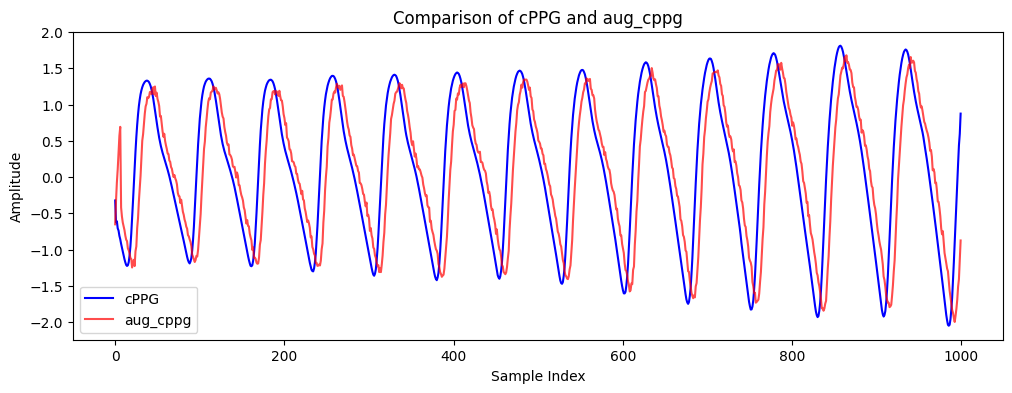

In [143]:
# --- Plot comparison ---
plt.figure(figsize=(12,4))
plt.plot(cppg_norm[idx_healthy], label="cPPG", color='blue')
plt.plot(aug_cppg[idx_healthy], label="aug_cppg", color='red', alpha=0.7)
plt.title("Comparison of cPPG and aug_cppg")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


In [148]:
np.save("aug_cppg.npy", aug_cppg)
n_train, n_samples = aug_cppg.shape
print(n_train, n_samples)

35120 1000


In [147]:
np.save("rPPG_filtered.npy", segments_filtered)
n, n = segments_filtered.shape
print(n, n)

1000 1000
